# Quick looks opening data in /perm/ 

In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import pint
from pint import UnitRegistry
ureg = UnitRegistry()
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun

In [4]:
dir_in   = "/perm/paaa/IFS/cabauw"
dir_obs = "/perm/paaa/Cesar"
exp_names = ['Cabauw_SPPoff_dryMFv1','Cabauw_SPPon_conv'] 
# exp_names = ['Cabauw_SPPoff_TKEon','Cabauw_SPPoff_TKEoff','Cabauw_SPPoff_dryMFv1'] 
exp_names = ['Cabauw_SPPoff_dryMFv1','Cabauw_SPPon','Cabauw_SPPon_conv'] 

exp_lab = ['Ctrl', 'SPP', 'SPP-conv']
# exp_lab = ['dryMF', 'SPP-conv']

str_time = '2022-05-15'
end_time = '2022-05-20'
end_time = '2022-05-16'

col = ['#D04848','#6895D2','#F3B95F','#59981A']
sty = ['--','-',':']

## Open obs

In [5]:
obs_name = "cesar_surface_flux"
datestamp = "2022"

files = [os.path.join(dir_obs, f) for f in os.listdir(dir_obs) if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_surf_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_surf_flx['time'] = obs_surf_flx['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')
obs_surf_flx


FileNotFoundError: [Errno 2] No such file or directory: '/perm/paaa/Cesar'

In [6]:
obs_surf_flx_hr = obs_surf_flx.resample(time='1H',label='right').mean()

NameError: name 'obs_surf_flx' is not defined

## Open IFS data

In [7]:
ds_srf_slab = {}
ds_z_slab  = {}
for exp in exp_names:
    for levels in ['srf','z']:
        ## open dataset 
        files = [os.path.join(dir_in, f) for f in os.listdir(dir_in) if exp+'_'+levels in f and f.endswith('.nc')]
        ds    = xr.open_mfdataset(files,combine='by_coords')
        # convert UTC to local time (+2 hours)
        ds['time'] = ds['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')

        if levels =='z':
            ds_z_slab[exp] = ds.mean(('latitude','longitude'),keep_attrs=True)
            if 'wspd' not in ds:
                ds['wspd'] = mfun.pitagora_fun(ds['u'],ds['v'])
                # ds['wspd'].attrs['units'] = ds['u'].attrs['units']
            ## Combine tendencies into total, only if they don't already exist
            for var in ['q', 'T']:
                var_name = f'd{var}dt_tot'
                if var_name not in ds and f'd{var}dt_diff' in ds:
                    ds[var_name] = (ds[f'd{var}dt_dyn'] +
                                            ds[f'd{var}dt_diff'] +
                                            ds[f'd{var}dt_conv'] +
                                            ds[f'd{var}dt_cloud'])
            for var in ['u', 'v', 'co2', 'ch4']:
                var_name = f'd{var}dt_tot'
                if var_name not in ds and f'd{var}dt_diff' in ds:
                    ds[var_name] = (ds[f'd{var}dt_dyn'] +
                                            ds[f'd{var}dt_diff'] +
                                            ds[f'd{var}dt_conv'])
                if var =='co2':
                    ds[var+'_ppm'] = mfun.concentration_to_ppm('co2',ds[var]/1000)
                    ds[var+'_ppm'].attrs['units'] = 'PPM'
                    ds[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'
            ds_z_slab[exp] = ds.mean(('latitude','longitude'),keep_attrs=True)
        elif levels == 'srf':
            ds_srf_slab[exp] = ds.mean(('latitude','longitude'),keep_attrs=True)
    
time_values = ds['time'].values  # Extract the time values



# Plotting

In [8]:
import numpy as np

xp = np.array([0, 1, 2])      # x-coordinates (sorted ascending)
fp = np.array([0, 10, 20])    # corresponding y-coordinates

x = np.array([-1, 0.5, 3])    # query points

y = np.interp(x, xp, fp)
print(y)

[ 0.  5. 20.]


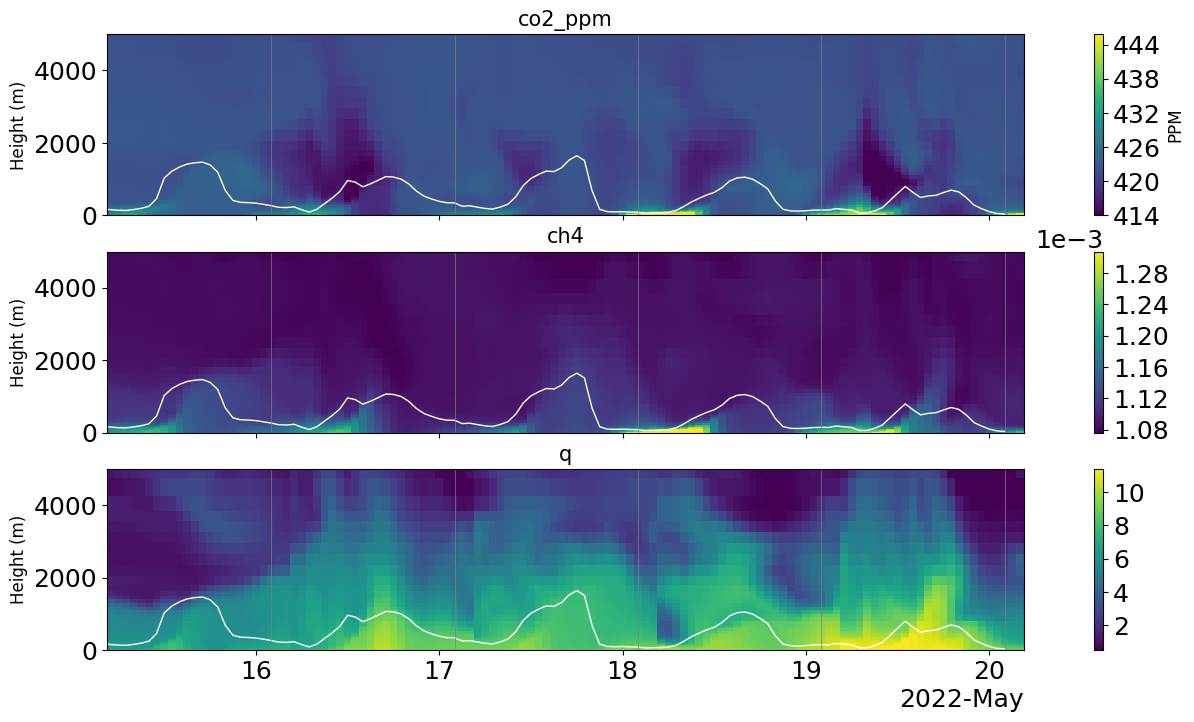

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13, 8), sharex=True)
exp = exp_names[1]

# Top panel for 'exp'
for ide, var in enumerate(['co2_ppm','ch4','q']):
    data = ds_z_slab[exp][var]  # Extract the variable data
    vmin = data.quantile(0.01).values  # 10th percentile
    vmax = data.quantile(0.99).values  # 90th percentile
    # vmin = 0.2
    # vmax = 0.7
    units = data.attrs.get('units', '')  # Use empty string if 'units' is not set
    if var == 'cc':
        cmap = 'Blues_r'
        norm = None
    elif var in['u','v']:
        cmap ='coolwarm'
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        cmap = 'viridis'
        norm = None

    im = data.plot(ax=axes[ide], x='time',vmax=vmax,vmin=vmin,add_colorbar=False, cmap=cmap, norm =norm)

    # Set scientific notation for the colourbar
    cbar = plt.colorbar(im, ax=axes[ide], orientation='vertical',fraction=0.02, pad=0.07)
    cbar.formatter = ticker.ScalarFormatter()
    cbar.formatter.set_scientific(True)
    cbar.formatter.set_powerlimits((-2, 3))  # Set the same power limits as the axis
    cbar.update_ticks()
    cbar.set_label(f"{units}", fontsize=12)
    cbar.locator = ticker.MaxNLocator(nbins=6)
    cbar.update_ticks()

    # plot BL height
    ds_srf_slab[exp]['blh'].plot(ax=axes[ide],x='time',c='white',lw=1)

    axes[ide].set_ylim([0,5000])         
    axes[ide].set_title(var, fontsize=15) 
    axes[ide].set_ylabel('Height (m)', fontsize=12)  
    axes[ide].set_xlabel('')   

    for i in range(21, len(time_values), 24):  # Start from 23, step by 24
        axes[ide].axvline(time_values[i], color='grey', lw=0.5)

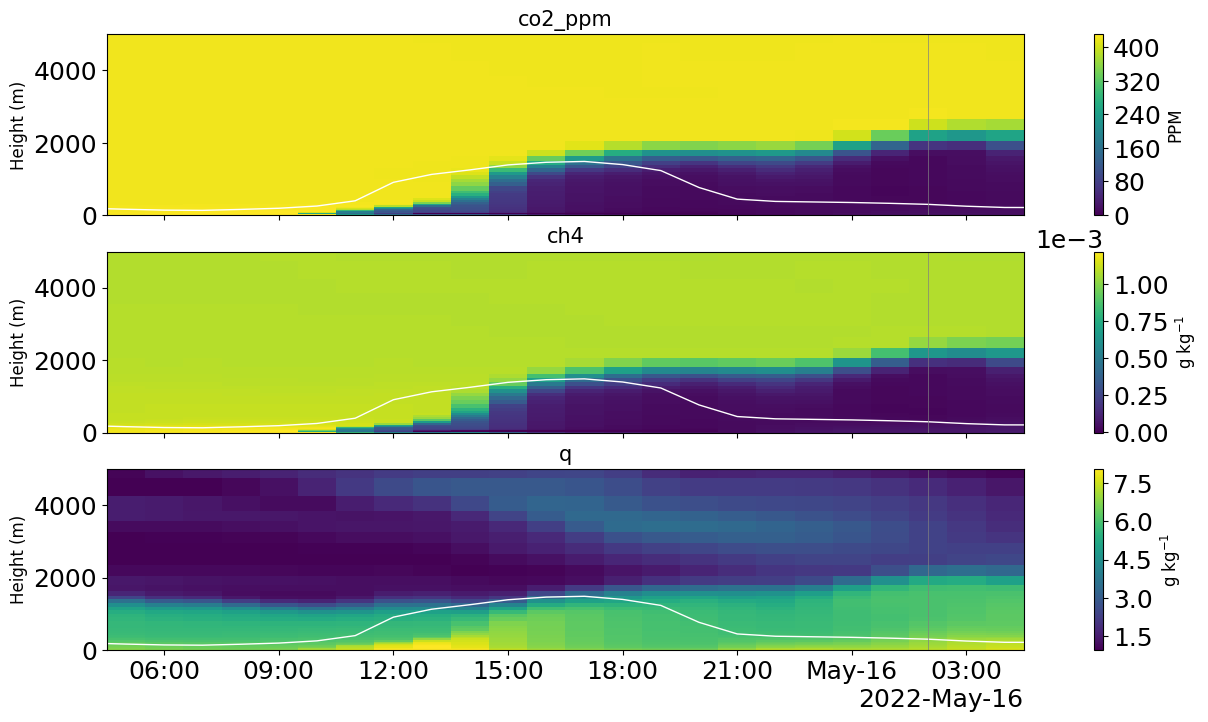

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13, 8), sharex=True)
exp = exp_names[0]

# Top panel for 'exp'
for ide, var in enumerate(['co2_ppm','ch4','q']):
    data = ds_z_slab[exp][var]  # Extract the variable data
    vmin = data.quantile(0.01).values  # 10th percentile
    vmax = data.quantile(0.99).values  # 90th percentile
    # vmin = 0.2
    # vmax = 0.7
    units = data.attrs.get('units', '')  # Use empty string if 'units' is not set
    if var == 'cc':
        cmap = 'Blues_r'
        norm = None
    elif var in['u','v']:
        cmap ='coolwarm'
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        cmap = 'viridis'
        norm = None

    im = data.plot(ax=axes[ide], x='time',vmax=vmax,vmin=vmin,add_colorbar=False, cmap=cmap, norm =norm)

    # Set scientific notation for the colourbar
    cbar = plt.colorbar(im, ax=axes[ide], orientation='vertical',fraction=0.02, pad=0.07)
    cbar.formatter = ticker.ScalarFormatter()
    cbar.formatter.set_scientific(True)
    cbar.formatter.set_powerlimits((-2, 3))  # Set the same power limits as the axis
    cbar.update_ticks()
    cbar.set_label(f"{units}", fontsize=12)
    cbar.locator = ticker.MaxNLocator(nbins=6)
    cbar.update_ticks()

    # plot BL height
    ds_srf_slab[exp]['blh'].plot(ax=axes[ide],x='time',c='white',lw=1)

    axes[ide].set_ylim([0,5000])     
    axes[ide].set_title(var, fontsize=15) 
    axes[ide].set_ylabel('Height (m)', fontsize=12)  
    axes[ide].set_xlabel('')   

    for i in range(21, len(time_values), 24):  # Start from 23, step by 24
        axes[ide].axvline(time_values[i], color='grey', lw=0.5)

Text(0.5, 1.0, 'Mean between 1000 and 850 hPa')

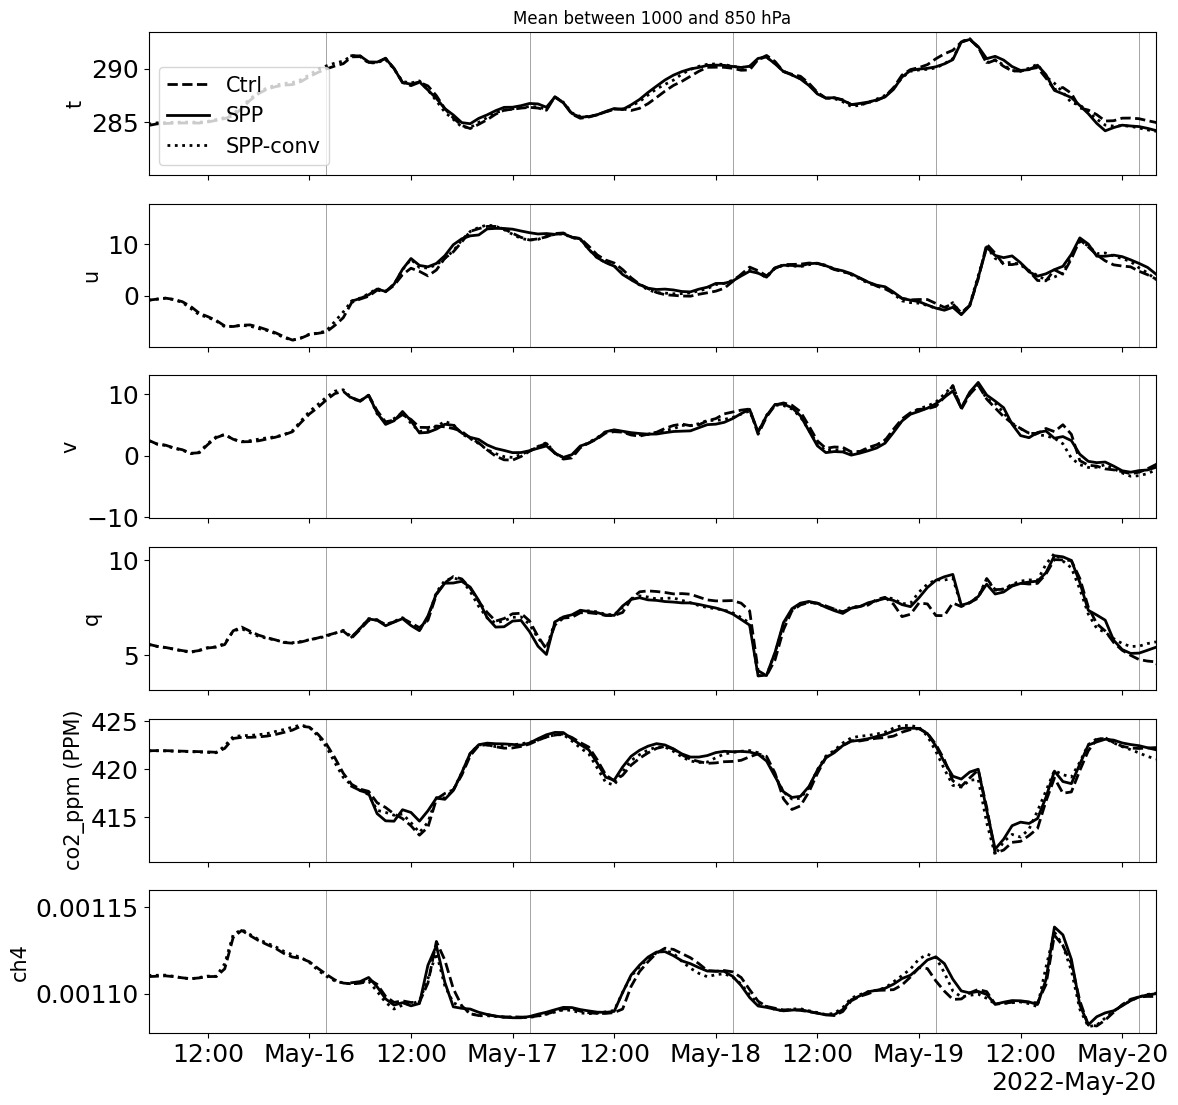

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(13, 13), sharex=True)
# Top panel for 'exp'
for idx, var in enumerate(['t','u','v','q','co2_ppm','ch4']):
    variable = ds_z_slab[exp_names[0]][var]
    # Retrieve the variable name and units attribute
    var_name = variable.name
    units = variable.attrs.get('units', '')  # Use empty string if 'units' is not set
    # Create the label with units
    y_label = f"{var_name} ({units})" if units else var_name
    

    axes[idx].set_xlim([time_values[0],time_values[-1]])
    for i in range(21, len(time_values), 24):  # Start from 23, step by 24
        axes[idx].axvline(time_values[i], color='grey', lw=0.5)

    for ide, exp in enumerate(exp_names): 
        ds_z_slab[exp][var].sel(height=slice(850,1000)).mean('height').plot(
            ax=axes[idx],lw=2,label=exp_lab[ide],c='k',ls=sty[ide])
    
    axes[idx].set_ylabel(y_label, fontsize=15)
    # Remove x-tick labels for all subplots except the last one
    if idx != len(axes) - 1:
        axes[idx].set_xlabel(None)
        axes[idx].set_xticklabels([])
    else:
        axes[idx].set_xlabel('', fontsize=15)  # Keep x-label for the last subplot
        
axes[0].legend(fontsize=15)
axes[0].set_title('Mean between 1000 and 850 hPa')
    


No tendencies on model levels for Cabauw_SPPoff_TKEoff


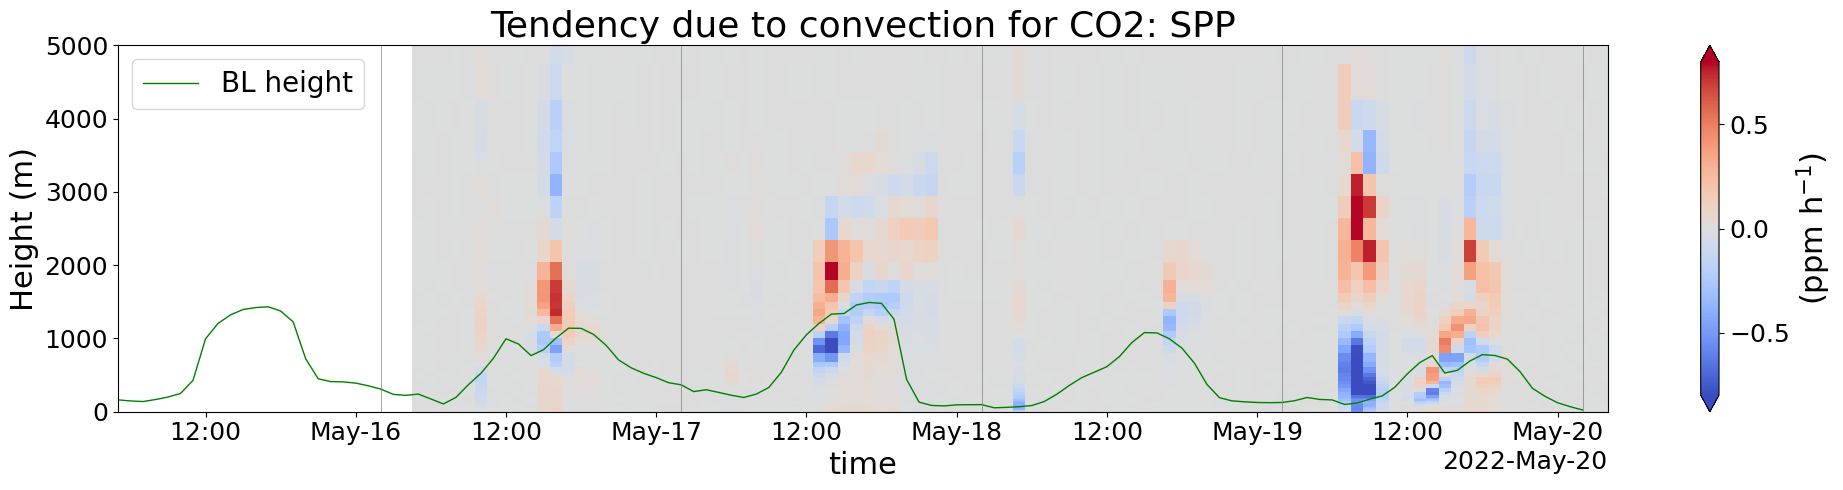

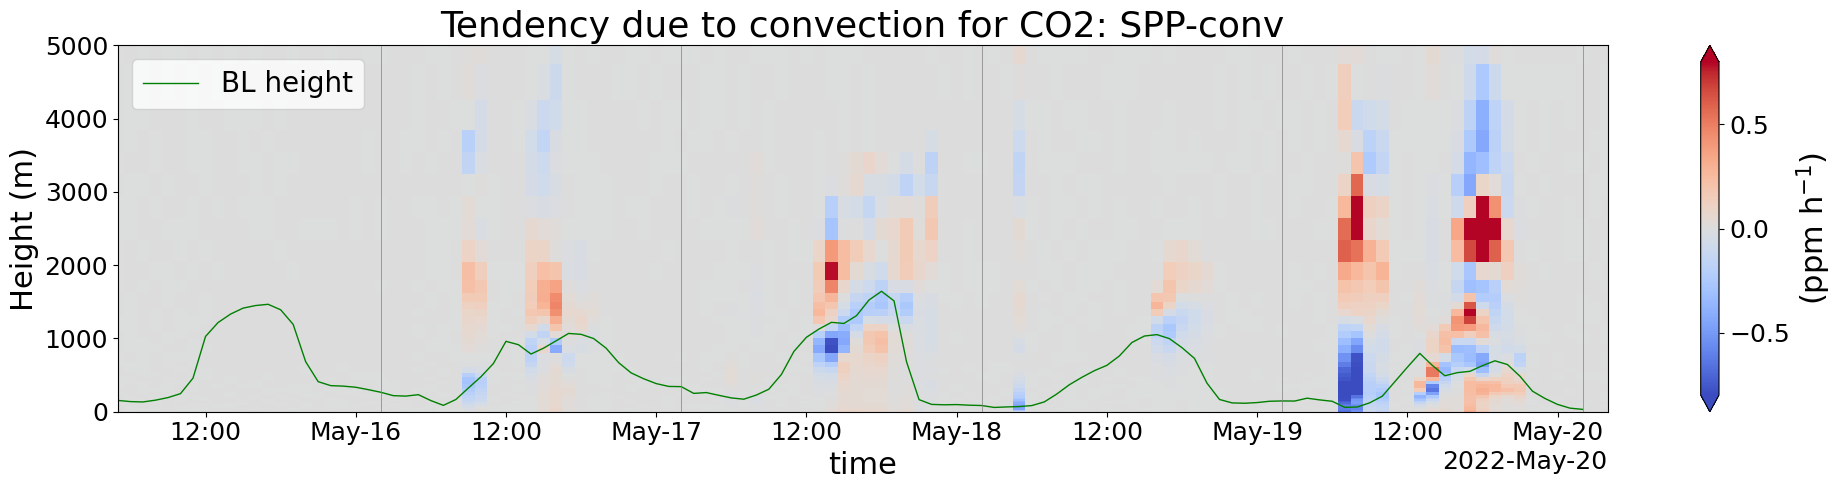

In [ ]:
var = 'co2'
# unit = ds_pl_slab[exp]['d'+var+'dt_diff'].attrs.get('units', '')  # Default to an empty string if 'unit' is missing
unit = r'ppm h$^{-1}$'
for ide, exp in enumerate(exp_names):
    if ide ==0: 
        print('No tendencies on model levels for '+exp)
    else: 
        plt.figure(figsize=[20, 5])
        data = mfun.concentration_to_ppm('co2',ds_z_slab[exp]['d'+var+'dt_conv']/1000)  # Extract the variable data

        # vmin = data.quantile(0.0006).values  # 10th percentile
        vmin = -0.0015  # 10th percentile
        vmin = -0.8


        # Plot the data
        ax = data.plot(x='time', cbar_kwargs={'label': f'({unit})'}, vmin=vmin,cmap='coolwarm',)

        # Format the colorbar labels in scientific notation
        cbar = ax.colorbar
        cbar.formatter = ticker.ScalarFormatter(useMathText=True)
        cbar.formatter.set_scientific(True)
        cbar.formatter.set_powerlimits((-3, 3))  # Adjust exponent threshold if needed
        cbar.update_ticks()

        # Plot BL height
        ds_srf_slab[exp]['blh'].plot(x='time', c='g', lw=1,label='BL height')

        # Add vertical lines
        for i in range(21, len(time_values), 24):  
            plt.axvline(time_values[i], color='grey', lw=0.5)

        plt.legend(fontsize=20)
        plt.xlim([time_values[0], time_values[-1]])
        plt.ylim([0, 5000])
        plt.ylabel('Height (m)')
        plt.title(f'Tendency due to convection for {var.upper()}: {exp_lab[ide]}', fontsize=26)
        plt.tight_layout()

Text(0.5, 1.0, 'CO2 budget between 500 and 700 hPa')

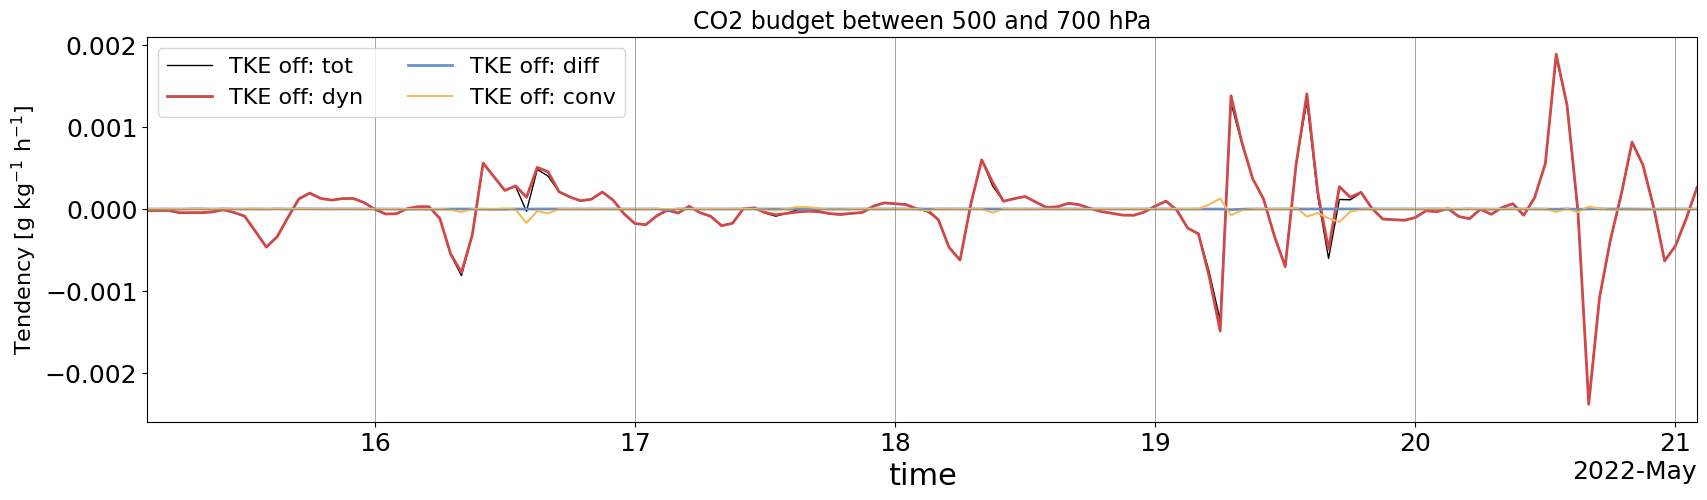

In [ ]:
var = 'co2'
unit = ds_pl_slab[exp]['d'+var+'dt_conv'].attrs.get('units', '')  # Default to an empty string if 'unit' is missing

plt.figure(figsize=[20,5])
for ide,exp in enumerate([exp_names[0],]):
    ds_mean = ds_pl_slab[exp].sel(level=slice(500,700)).mean('level')
    ds_mean['d'+var+'dt_tot'].plot(x='time',label=exp_lab[ide]+': tot',c='k',lw=1,ls=sty[ide+1])
    ds_mean['d'+var+'dt_dyn'].plot(x='time',label=exp_lab[ide]+': dyn',c=col[0],lw=2,ls=sty[ide+1])
    ds_mean['d'+var+'dt_diff'].plot(x='time',label=exp_lab[ide]+': diff',c=col[1],lw=2,ls=sty[ide+1])
    ds_mean['d'+var+'dt_conv'].plot(x='time',label=exp_lab[ide]+': conv',c=col[2],lw=1.5,ls=sty[ide+1])
    if var in ['q','T']:
        ds_mean['d'+var+'dt_cloud'].plot(x='time',label='Cloud',lw=2)
for i in range(21, len(time_values), 24):  # Start from 23, step by 24
    plt.axvline(time_values[i], color='grey', lw=0.5)
plt.axhline(0,c='grey',lw=0.5)
plt.legend(fontsize=16,ncol=2)
plt.xlim([time_values[0],time_values[-1]])
# plt.ylim([-0.00003,0.00003])
plt.ylabel(f'Tendency [{unit}]',fontsize=16)
plt.title('CO2 budget between 500 and 700 hPa',fontsize=17)

No tendencies for Cabauw_SPPoff_TKEoff
No tendencies for Cabauw_SPPoff_TKEoff


/etc/ecmwf/ssd/ssd1/tmpdirs/paaa.3945051.20250317_121821.524/ipykernel_3962136/817203147.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idy,2].legend(fontsize=15,loc='upper right')


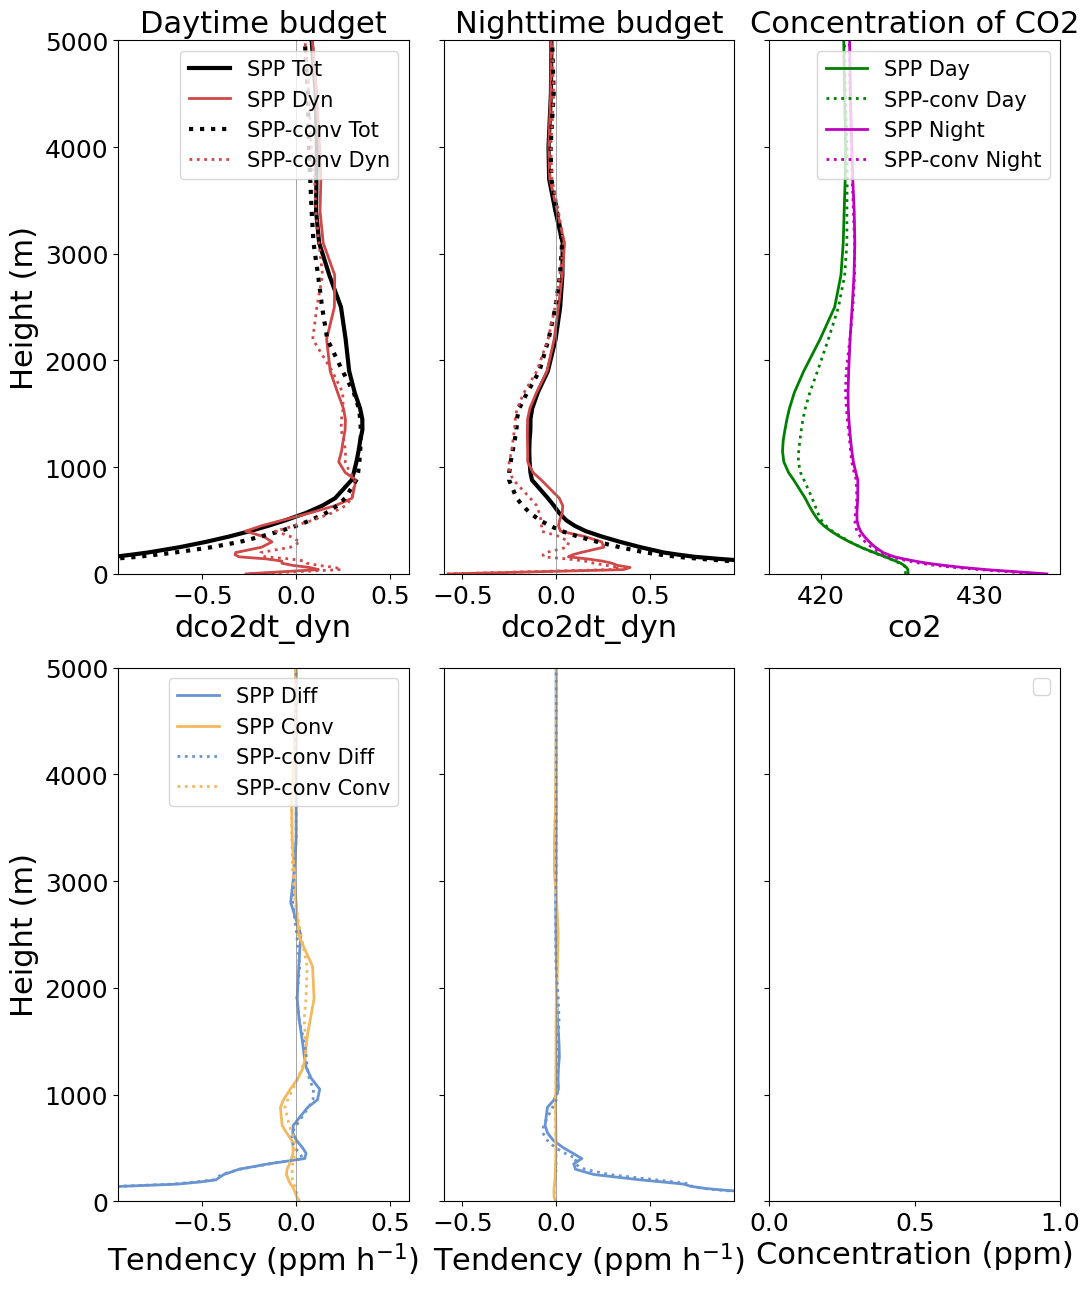

In [ ]:
hours_day   =[9 ,10,11,12,13,14,15,16,17] # daytime
hours_night =[21,22,23,0 ,1 ,2 ,3 ,4 ,5 ] # nighttime
# hours =[2,3,4,5,6,7,8]

var = 'co2'
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 13))

for idx, hours in enumerate([hours_day,hours_night]):
    for ide,exp in enumerate(exp_names):
        if ide ==0:
            print('No tendencies for '+ exp)
        else:

            ds_filtered = ds_z_slab[exp].sel(time=slice(str_time, end_time)) # Select days
            ds_filtered = ds_filtered.sel(time=ds_filtered['time'].dt.hour.isin(hours))  # Select hours
            # ds_mean = ds_filtered.mean('time',keep_attrs=True)
            ds_mean = mfun.concentration_to_ppm('co2',ds_filtered/1000).mean('time',keep_attrs=True)



            ds_mean['d'+var+'dt_tot'].plot(ax=axes[0,idx], y='height', label=exp_lab[ide]+ ' Tot'  ,c='k'   ,
                                        lw=3,ls=sty[ide])
            ds_mean['d'+var+'dt_dyn'].plot(ax=axes[0,idx], y='height', label=exp_lab[ide]+ ' Dyn'  ,c=col[0],
                                        lw=2,ls=sty[ide])
            ds_mean['d'+var+'dt_diff'].plot(ax=axes[1,idx],y='height', label=exp_lab[ide]+ ' Diff' ,c=col[1],
                                            lw=2,ls=sty[ide])
            ds_mean['d'+var+'dt_conv'].plot(ax=axes[1,idx],y='height', label=exp_lab[ide]+ ' Conv' ,c=col[2],
                                            lw=2,ls=sty[ide])

            # ds_mean['d'+var+'dt_tot'].plot(ax=axes[0], y='level', yincrease=False, label=exp_lab[ide]+': tot'  ,c='k'   ,
            #                                lw=3,ls=sty[ide])
            # ds_mean['d'+var+'dt_dyn'].plot(ax=axes[0], y='level', yincrease=False, label=exp_lab[ide]+': dyn'  ,c=col[0],
            #                                lw=2,ls=sty[ide])
            # ds_mean['d'+var+'dt_diff'].plot(ax=axes[0],y='level', yincrease=False, label=exp_lab[ide]+': diff' ,c=col[1],
            #                                 lw=2,ls=sty[ide])
            # ds_mean['d'+var+'dt_conv'].plot(ax=axes[0],y='level', yincrease=False, label=exp_lab[ide]+': conv' ,c=col[2],
            #                                 lw=2,ls=sty[ide])
            # if var in ['q','T']:
            #     ds_mean['d'+var+'dt_cloud'].plot(ax=axes[0],y='level',yincrease=False,label=exp_lab[ide]+': cloud',c=col[3], lw=2,ls=sty[ide])

            ds_mean[var].plot(ax=axes[0,2], y='height', lw=2, label=exp_lab[ide]+[' Day',' Night'][idx],c=['g','m'][idx],ls=sty[ide])

for idy in [0,1]:
    for idx in [0,1,2]:
        axes[idy,idx].set_ylim([0,5000])
        axes[idy,idx].set_title('', fontsize =22)
    axes[idy,0].axvline(0,c='grey',lw=0.5)
    axes[idy,1].axvline(0,c='grey',lw=0.5)
    axes[idy,0].set_xlim([-0.95,0.6])
    axes[idy,1].set_xlim([-0.6,0.95])

    axes[idy,0].legend(fontsize=15)
    axes[idy,2].legend(fontsize=15,loc='upper right')
    axes[idy,0].set_ylabel('Height (m)')
    axes[idy,1].set_ylabel('')
    axes[idy,1].set_yticklabels([])
    axes[idy,2].set_ylabel('')
    axes[idy,2].set_yticklabels([])
    # unit_tend = ds_mean['d'+var+'dt_dyn'].attrs.get('units', '')
    # unit_conc = ds_mean[var].attrs.get('units', '')
    unit_tend = r'ppm h$^{-1}$'
    unit_conc = r'ppm'

    # Set scientific notation on the x-axis
    axes[idy,0].ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
    axes[idy,1].ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
    # axes[0].set_title('Budget of '+var.upper(), fontsize =22)
axes[1,0].set_xlabel(f'Tendency ({unit_tend})')
axes[1,1].set_xlabel(f'Tendency ({unit_tend})')
axes[1,2].set_xlabel(f'Concentration ({unit_conc})')
axes[0,0].set_title('Daytime budget', fontsize =22)
axes[0,1].set_title('Nighttime budget', fontsize =22)
axes[0,2].set_title('Concentration of '+var.upper(), fontsize =22)

plt.tight_layout()


## Diurnal cycle 

In [28]:
var = 'co2'
unit_ten = ds_pl_slab[exp]['d'+var+'dt_conv'].attrs.get('units', '')  # Default to an empty string if 'unit' is missing
unit_conc = ds_pl_slab[exp][var].attrs.get('units', '')  # Default to an empty string if 'unit' is missing

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), sharex=True)
for ide,exp in enumerate([exp_names[0],]):
    hourly_composite = ds_pl_slab[exp].sel(level=slice(850,1000)).mean('level').groupby(ds_pl_slab[exp].time.dt.hour).mean(dim="time")
    # First row for the tendency
    hourly_composite['d'+var+'dt_tot'].plot(ax=axes, x='hour',label=exp_lab[ide]+': tot' , c='k'   , lw=1  , ls=sty[ide+1])
    hourly_composite['d'+var+'dt_dyn'].plot(ax=axes, x='hour',label=exp_lab[ide]+': dyn' , c=col[0], lw=2  , ls=sty[ide+1])
    hourly_composite['d'+var+'dt_diff'].plot(ax=axes,x='hour',label=exp_lab[ide]+': diff', c=col[1], lw=2  , ls=sty[ide+1])
    hourly_composite['d'+var+'dt_conv'].plot(ax=axes,x='hour',label=exp_lab[ide]+': conv', c=col[2], lw=1.5, ls=sty[ide+1])
    if var in ['q','T']:
        hourly_composite['d'+var+'dt_cloud'].plot(ax=axes,x='hour',label=exp_lab[ide]+': cloud', c=col[3], lw=2, ls=sty[ide+1])

    # Create a secondary axis
    ax2 = axes.twinx()
    # Second row for the concentration
    hourly_composite[var].plot(ax=ax2, x='hour',label=exp_lab[ide] , c='k'   , lw=3  , ls=sty[ide])

axes.axhline(0,c='grey',lw=0.5)
axes.legend(fontsize=15,ncol=2,loc='lower center')
axes.set_xlim([0,23])
# plt.ylim([-0.00003,0.00003])
axes.set_ylabel(f'Tendency [{unit_ten}]',fontsize=15)
ax2.set_ylabel(f'Concentration [{unit_conc}]',fontsize=15)
axes.set_title('Diurnal cycle of '+var+' between 850 and 1000 hPa', fontsize =16)


NameError: name 'ds_pl_slab' is not defined

Text(0.5, 1.0, 'Diurnal cycle of CO$_2$ between 0 and 100 m')

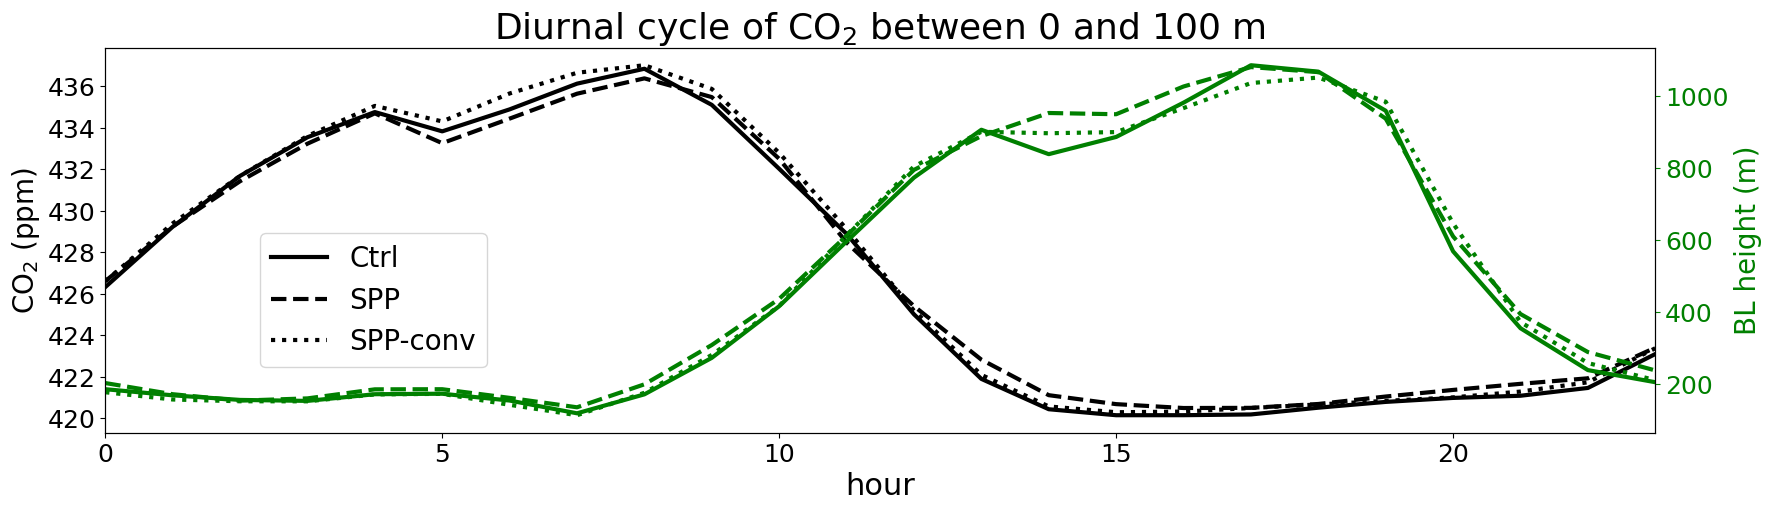

In [26]:
var = 'co2_ppm'
unit_conc = ds_z_slab[exp][var].attrs.get('units', '')  # Default to an empty string if 'unit' is missing

common_time = np.intersect1d(
                np.intersect1d(
                    np.intersect1d(
                        ds_z_slab['Cabauw_SPPon'].time.values, ds_z_slab['Cabauw_SPPon_conv'].time.values),
                ds_z_slab['Cabauw_SPPoff_dryMFv1'].time.values),ds_srf_slab['Cabauw_SPPon'].time.values)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), sharex=True)
# Create a secondary axis
ax2 = axes.twinx()
for ide,exp in enumerate(exp_names):
    hourly_composite = ds_z_slab[exp].sel(time=common_time).sel(height=slice(30,100)).mean('height').groupby('time.hour').mean(dim="time")
    hourly_composite_srf = ds_srf_slab[exp].sel(time=common_time).groupby('time.hour').mean(dim="time")

    # Plot the concentration
    hourly_composite[var].plot(ax=axes, x='hour',label=exp_lab[ide] , c='k'   , lw=3  , ls=sty[ide])

    hourly_composite_srf['blh'].plot(ax=ax2, x='hour' , c='g'   , lw=3  , ls=sty[ide])


# Ensure integer ticks and set exactly 5 tick locations for the primary y-axis
axes.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
axes.legend(fontsize=20,ncol=1,loc=[0.1,0.17])
axes.set_xlim([0,23])
# plt.ylim([-0.00003,0.00003])
axes.set_ylabel(f'CO$_2$ ({unit_conc.lower()})',fontsize=20)
ax2.set_ylabel(f'BL height (m)',fontsize=20,c='g')
ax2.tick_params(axis='y', colors='g')
axes.set_title(r'Diurnal cycle of CO$_2$ between 0 and 100 m', fontsize =26)

In [54]:

sty = ['-', '--', '--']

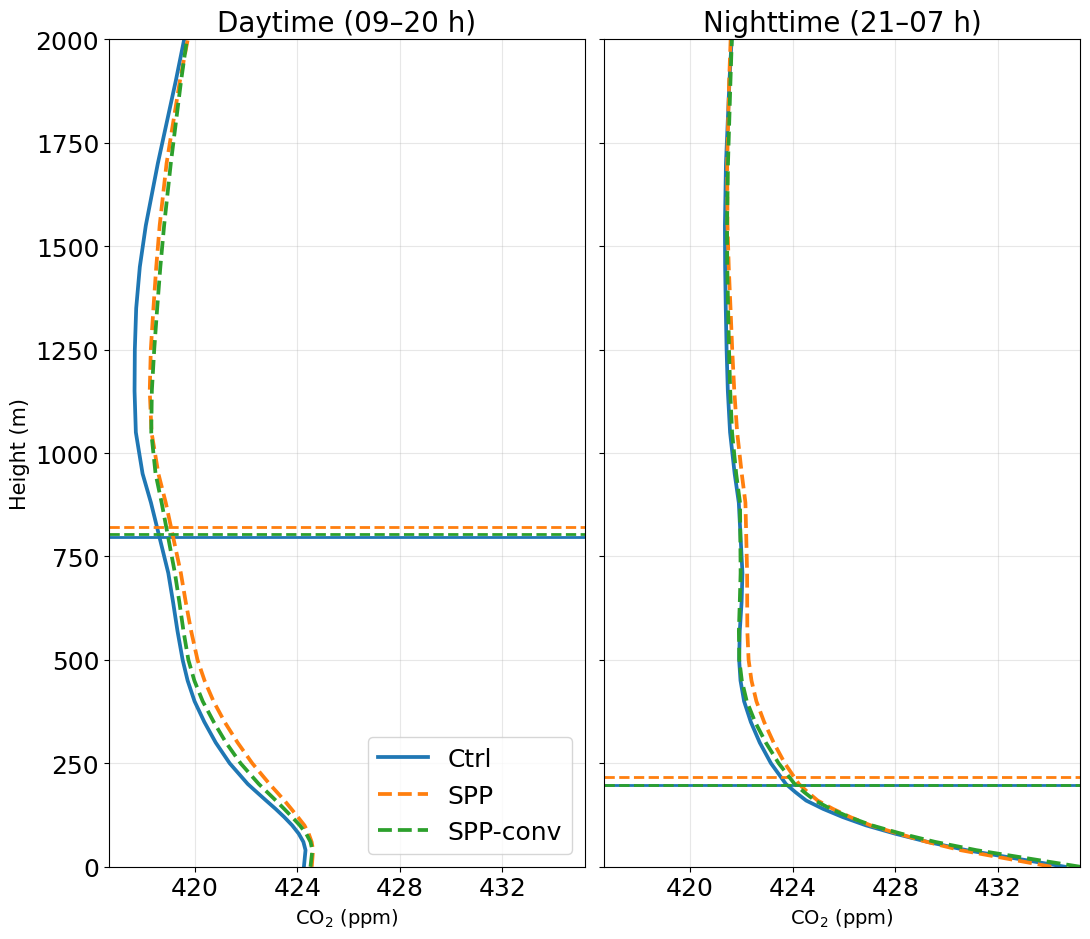

In [57]:
var = 'co2_ppm'
unit_conc = ds_z_slab[exp_names[0]][var].attrs.get('units', '')
max_y = 2000

# Define day and night hours
day_hours = np.arange(9, 20)     # 06–17
night_hours = np.concatenate((np.arange(21, 24), np.arange(0, 7)))  # 18–23 and 00–05

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 10), sharey=True)
ax_day, ax_night = axes

# Keep track of global x-limits so panels are comparable
global_xmin = np.inf
global_xmax = -np.inf
cmap = plt.get_cmap('tab10')

for ide, exp in enumerate(exp_names):
    # select times common to all experiments first (you already computed common_time)
    ds_vert = ds_z_slab[exp].sel(time=common_time).sel(height=slice(0,max_y+200))
    ds_srf = ds_srf_slab[exp].sel(time=common_time)

    # boolean masks for day and night times
    hours = ds_vert['time.hour'].values
    day_mask = np.isin(hours, day_hours)
    night_mask = np.isin(hours, night_hours)

    # mean vertical profile over all times that are in the given mask
    # note: indexing with .sel(time=ds_vert['time'][mask]) preserves times selected
    if day_mask.any():
        prof_day = ds_vert[var].sel(time=ds_vert['time'][day_mask]).mean(dim='time')
    else:
        # fallback to an empty array to avoid errors
        prof_day = None

    if night_mask.any():
        prof_night = ds_vert[var].sel(time=ds_vert['time'][night_mask]).mean(dim='time')
    else:
        prof_night = None

    # BLH: mean over the same times, computed safely (Dask -> compute)
    if hasattr(ds_srf['blh'], "time"):
        if day_mask.any():
            blh_day = ds_srf['blh'].sel(time=ds_srf['time'][day_mask]).mean(dim='time').compute().values
        else:
            blh_day = np.nan
        if night_mask.any():
            blh_night = ds_srf['blh'].sel(time=ds_srf['time'][night_mask]).mean(dim='time').compute().values
        else:
            blh_night = np.nan
    else:
        blh_day = np.nan
        blh_night = np.nan

    # Prepare height coordinate (assume 'height' coordinate exists)
    # Use the profile that exists (day or night) to grab heights
    if prof_day is not None:
        h_day = prof_day['height'].values
        x_day = prof_day.compute().values  # compute to numpy
        ax_day.plot(x_day, h_day, label=exp_lab[ide], lw=2.7, ls=sty[ide],c=cmap(ide))
        # update global x-lims
        global_xmin = min(global_xmin, np.nanmin(x_day)-1)
        global_xmax = max(global_xmax, np.nanmax(x_day))
        # BLH horizontal line
        if not np.isnan(blh_day):
            ax_day.axhline(blh_day,c=cmap(ide),ls=sty[ide],lw=2)
    else:
        # nothing to plot for day
        pass

    if prof_night is not None:
        h_night = prof_night['height'].values
        x_night = prof_night.compute().values
        ax_night.plot(x_night, h_night, label=exp_lab[ide], lw=2.7, ls=sty[ide],c=cmap(ide))
        global_xmin = min(global_xmin, np.nanmin(x_night))
        global_xmax = max(global_xmax, np.nanmax(x_night))
        if not np.isnan(blh_night):
            ax_night.axhline(blh_night,c=cmap(ide),ls=sty[ide],lw=2)
    else:
        pass

# formatting: axes labels, limits, ticks
for ax, title in zip((ax_day, ax_night), ['Daytime (09–20 h)', 'Nighttime (21–07 h)']):
    ax.set_xlabel(f'CO$_2$ ({unit_conc.lower()})', fontsize=14)
    ax.set_xlim([global_xmin if np.isfinite(global_xmin) else None,
                 global_xmax if np.isfinite(global_xmax) else None])
    ax.set_ylim(0,max_y)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
    ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=20)

# y-axis: height (shared)
ax_day.set_ylabel('Height (m)', fontsize=15)
ax_day.yaxis.set_major_locator(ticker.MaxNLocator(nbins=8, integer=True))
# legend on one panel (avoid duplicate legends)
ax_day.legend(fontsize=18, loc='lower right')

# fig.suptitle('Vertical profiles of CO$_2$ and BLH (horizontal green lines)', fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Difference between experiments

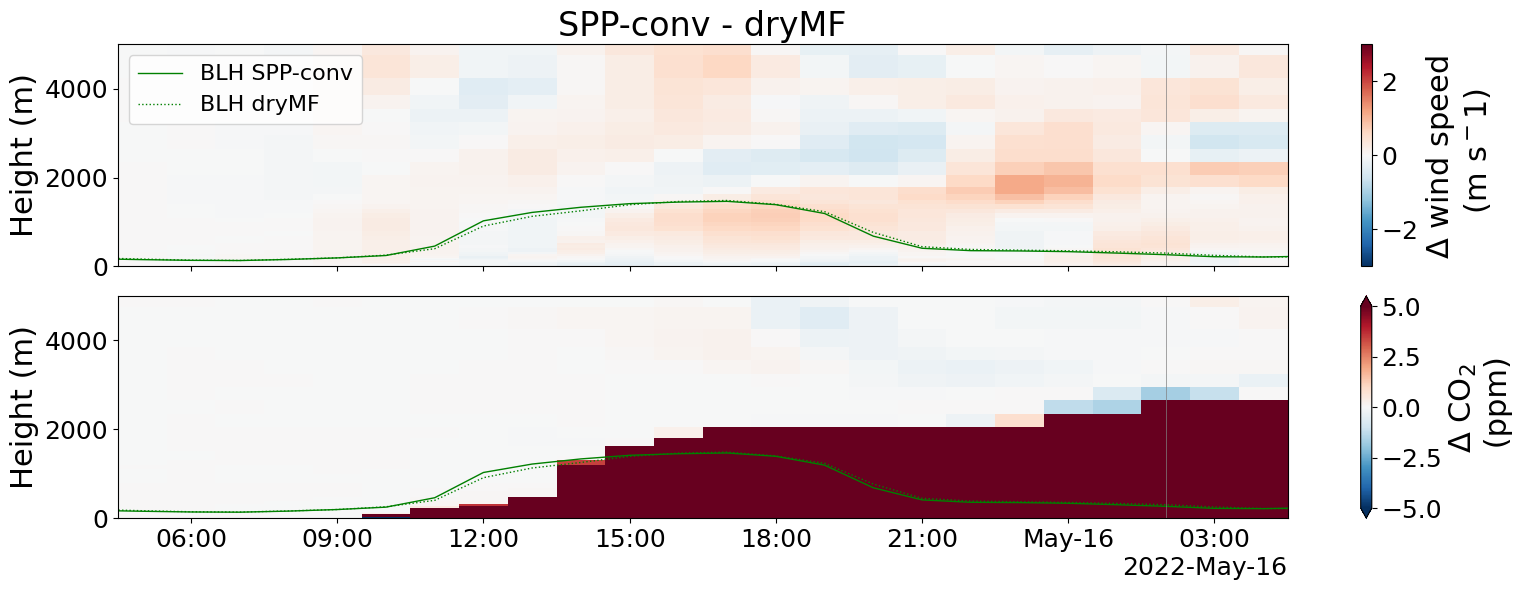

In [7]:
# difference betweeen experiments

exp1 = 1
exp2 = 0

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 6), sharex=True)
for idx, var in enumerate(['wspd','co2_ppm']):
    units = ds_z_slab[exp_names[exp1]][var].attrs.get('units', '')  # Use empty string if 'units' is not set
    long_name = ds_z_slab[exp_names[exp1]][var].attrs.get('long_name', '') 

    # Determine global min and max values for the colour scale
    # vmin = min(ds_z_slab[exp][var].min() for exp in exp_names).values
    # vmax = max(ds_z_slab[exp][var].max() for exp in exp_names).values
    # Compute the difference between the two experiments
    diff = ds_z_slab[exp_names[exp1]][var] - ds_z_slab[exp_names[exp2]][var]

    if var == 'co2_ppm':
        diff.plot(ax=axes[idx], x='time', cmap='RdBu_r',vmin= -5, 
            cbar_kwargs={'label': f'$\Delta$ CO$_2$ \n ({units.lower()})'})
    else:
        diff.plot(ax=axes[idx], x='time', cmap='RdBu_r',vmin=-3,
            # cbar_kwargs={'label': f'$\Delta$ {long_name} \n (m s$^{-1}$)'})
            cbar_kwargs={'label': f'$\Delta$ wind speed \n (m s$^{-1}$)'})
    # Plot BL height
    ds_srf_slab[exp_names[exp1]]['blh'].plot(ax=axes[idx],x='time', c='g', ls='-', lw=1,label='BLH '+exp_lab[exp1])
    ds_srf_slab[exp_names[exp2]]['blh'].plot(ax=axes[idx],x='time', c='g', ls=':', lw=1,label='BLH '+exp_lab[exp2])

# Add vertical lines to all subplots
for ax in axes:
    ax.set_ylim([0,5000])
    ax.set_ylabel('Height (m)')
    ax.set_xlabel('')
    for i in range(21, len(time_values), 24):  # Start from 23, step by 24
        ax.axvline(time_values[i], color='grey', lw=0.5)
axes[0].set_title(f'{exp_lab[exp1]} - {exp_lab[exp2]}',fontsize=24)
axes[0].legend(fontsize =16,loc='upper left')
# Improve layout
plt.tight_layout()

## PLOT dry MF

No tendencies on model levels for Cabauw_SPPoff_TKEoff


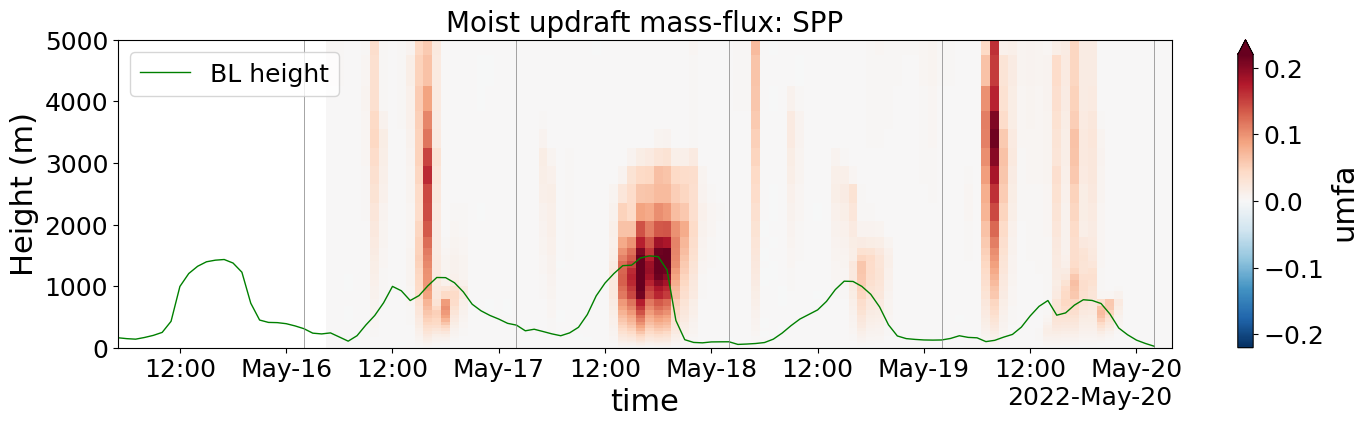

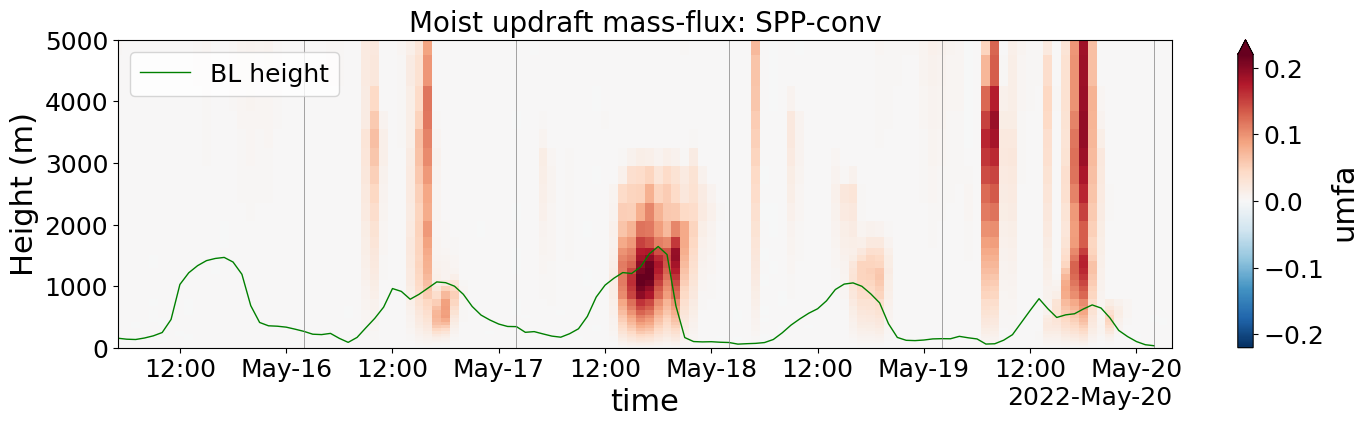

In [ ]:
for ide, exp in enumerate(exp_names):
    if ide ==0: 
        print('No tendencies on model levels for '+exp)
    else:
        plt.figure(figsize=(17,4))
        vmin=-0.22
        (ds_z_slab[exp]['umfa']/3600).plot(x='time',vmin=vmin)
        # Plot BL height
        ds_srf_slab[exp]['blh'].plot(x='time', c='g', lw=1,label='BL height')

        # Add vertical lines
        for i in range(21, len(time_values), 24):  
            plt.axvline(time_values[i], color='grey', lw=0.5)

        plt.legend(fontsize=18,loc='upper left')
        plt.xlim([time_values[0], time_values[-1]])
        plt.ylim([0, 5000])
        plt.ylabel('Height (m)')
        plt.title('Moist updraft mass-flux: '+exp_lab[ide],fontsize=20)


In [ ]:
|